In [1]:
! pip install pandas matplotlib seaborn nltk

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 4.1 MB/s eta 0:00:01
   --------------------------------- ------ 1.3/1.6 MB 3.7 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 3.1 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Loading tweets...

Quick peek at the sentiments:
                                                                      short_text  \
2013-07-18 09:39:46.071961602  ⚕️ Scientists conducted a Phase II study of ac...   
2013-07-17 03:40:32.173842437  This phase 2 Acalabrutinib-Venetoclax (AV) tri...   
2013-07-15 15:41:16.553048065  #NICE backs #AstraZenecas #Calquence for #CLL ...   
2013-07-12 19:19:42.367813635  #acalabrutinib is a valuable option in pts int...   
2013-07-04 12:40:34.334232586  NICE has recommended the use of acalabrutinib ...   

                              sentiment  
2013-07-18 09:39:46.071961602   Neutral  
2013-07-17 03:40:32.173842437  Positive  
2013-07-15 15:41:16.553048065  Negative  
2013-07-12 19:19:42.367813635  Positive  
2013-07-04 12:40:34.334232586  Positive  

Overall breakdown:
sentiment
Neutral     21421
Positive    15803
Negative     6123
Name: count, dtype: int64


C:\Users\vansh\AppData\Local\Temp\ipykernel_21932\651092900.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='Set2', order=['Positive', 'Neutral', 'Negative'])


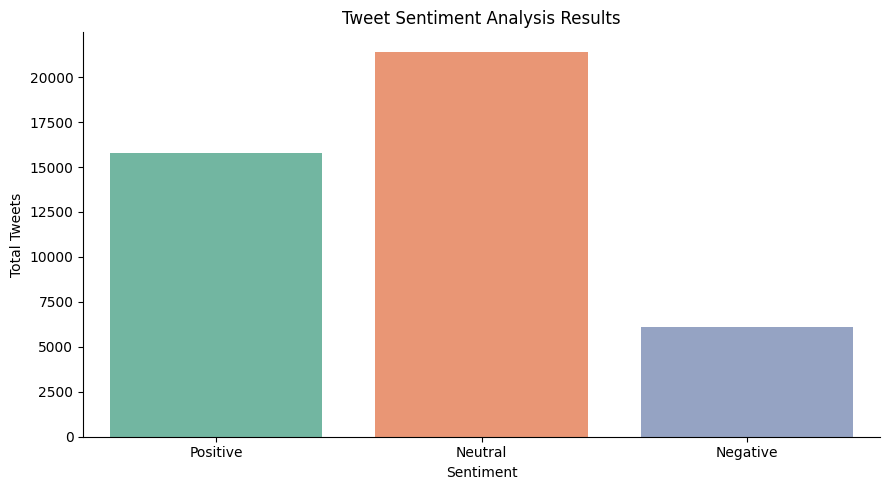

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Pull down the VADER lexicon if we don't have it yet
nltk.download('vader_lexicon', quiet=True)

# Load up the dataset
print("Loading tweets...")
try:
    # orient='index' tells pandas that the outer keys are our row labels
    df = pd.read_json('tweets.json', orient='index')
except FileNotFoundError:
    print("Couldn't find tweets.json. Make sure it's in the same folder as this notebook!")
    raise

# Drop any rows where the text might be missing
df.dropna(subset=['tweet_text'], inplace=True)

# Initialize the sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Simple helper to turn the compound score into a readable category
def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    return 'Neutral'

# Apply VADER to our tweet_text column
# Wrapping in str() just to be safe against any weird empty JSON values
df['compound_score'] = df['tweet_text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
df['sentiment'] = df['compound_score'].apply(categorize_sentiment)

# Let's see what we got
print("\nQuick peek at the sentiments:")
# Printing just a snippet of the text so it doesn't flood the console
df['short_text'] = df['tweet_text'].str[:60] + "..."
print(df[['short_text', 'sentiment']].head())

print("\nOverall breakdown:")
print(df['sentiment'].value_counts())

# Plot it out
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='sentiment', palette='Set2', order=['Positive', 'Neutral', 'Negative'])
plt.title('Tweet Sentiment Analysis Results')
plt.ylabel('Total Tweets')
plt.xlabel('Sentiment')

# Clean up the chart borders to make it look a bit more professional
sns.despine()
plt.tight_layout()
plt.show()